# 05b – Tuned gradient boosting: Secondary Mushroom

**Worked on by:** Andreas Schellekens (model choice, native missing-value handling, search space, threshold, test evaluation, deployable pipeline)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` to `05a_model_random_forest.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

Gradient boosting is the second tree ensemble from the top of the PyCaret comparison (LightGBM, CV AUC 0.809, notebook 04). We tune it with the same protocol as the random forest in `05a_model_random_forest.ipynb`: our own search space, ROC-AUC with 5-fold CV on the training set, a decision threshold for 90% recall on poisonous mushrooms, and one evaluation on the same test set.

Imports, paths and constants. `LOKY_MAX_CPU_COUNT` silences a harmless joblib warning on Windows and must be set before scikit-learn is imported.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
PREPARED_TRAIN_PATH = DATA_DIR / "mushroom_prepared_train.csv"
PREPARED_TEST_PATH = DATA_DIR / "mushroom_prepared_test.csv"
CLEANED_PATH = DATA_DIR / "mushroom_cleaned.csv"
MODEL_PATH = MODEL_DIR / "mushroom_gradient_boosting.joblib"
MODEL_INFO_PATH = MODEL_DIR / "mushroom_gradient_boosting.json"
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "05b_model_gradient_boosting"
RANDOM_STATE = 42
TARGET = "is_poisonous"
RECALL_TARGET = 0.90  # same target as the random forest (05a, section 5)
NUM_COLS = ["cap_diameter", "stem_height", "stem_width", "has_stem"]
CAT_COLS = ["spore_print_color", "gill_color", "habitat", "season", "ring_type", "cap_shape", "stem_surface"]
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}  # same colours as the EDA

We load the data in **two forms**, for the two variants in section 3:
- the **prepared** sets from notebook 02 (imputed, `log1p` + standardised, one-hot: 64 columns), as NumPy arrays like in 05a;
- the **cleaned** set, filtered on the `split` column: readable categories and numerical `NaN` still empty (11 columns).

Both contain exactly the same 4000 training and 1000 test rows, in the same order; the `assert` checks this.

In [2]:
train = pd.read_csv(PREPARED_TRAIN_PATH, index_col="row_id")
test = pd.read_csv(PREPARED_TEST_PATH, index_col="row_id")
X_train_prep, y_train = train.drop(columns=TARGET).to_numpy(), train[TARGET]
X_test_prep, y_test = test.drop(columns=TARGET).to_numpy(), test[TARGET]

cleaned = pd.read_csv(CLEANED_PATH)
X_train_native = cleaned.loc[train.index, NUM_COLS + CAT_COLS]
X_test_native = cleaned.loc[test.index, NUM_COLS + CAT_COLS]
assert (cleaned.loc[train.index, "split"] == "train").all() and (cleaned.loc[test.index, "split"] == "test").all()
assert ((cleaned.loc[train.index, "class"] == "poisonous").astype(int) == y_train).all()

print(f"Prepared: {X_train_prep.shape[1]} columns  |  cleaned: {X_train_native.shape[1]} columns")
print("Missing values in the cleaned training rows:", X_train_native.isna().sum()[lambda s: s > 0].to_dict())

Prepared: 64 columns  |  cleaned: 11 columns
Missing values in the cleaned training rows: {'cap_diameter': 1591, 'stem_height': 811, 'stem_width': 305, 'has_stem': 47}


## 2. Why gradient boosting, and why `HistGradientBoostingClassifier`?

**Boosting vs. the random forest.** A random forest trains many deep trees *independently* and averages them: averaging reduces the variance of the individual trees. Gradient boosting trains small trees **one after the other**: every new tree is fitted to the errors (more precisely, the gradient of the loss) of all previous trees together, and its contribution is multiplied by a small **learning rate**. It reduces the bias step by step. On many tabular datasets boosting is the strongest model family, so it is the natural competitor for the forest.

**Why scikit-learn's `HistGradientBoostingClassifier`** (HGB) instead of LightGBM:
- It is the same kind of algorithm: HGB was modelled on LightGBM (numerical values are binned into at most 255 bins, which makes finding a split fast).
- It is part of scikit-learn, so the API needs no extra library, and it avoids the LightGBM/PyCaret DLL conflict (notebook 04, section 1).
- It handles **missing values** and **categorical features** natively, which lets us test something new (section 3).

**Paths not taken:**
- *LightGBM* itself: very similar results in PyCaret (0.809), for the reasons above not worth an extra dependency.
- *XGBoost*: the third big boosting library. We use it on AWS SageMaker (`06_model_aws.ipynb`), where it is a built-in algorithm, so we do not train it here as well.
- *scikit-learn's older `GradientBoostingClassifier`*: slower, no missing-value support, and weaker in PyCaret (0.770).
- *CatBoost*: not installed; its main advantage (categorical features) is covered by HGB's native categorical support.

## 3. Two ways to feed the data

HGB can use the data in two ways, and we test both:

1. **prepared**: the 64 columns from our preprocessor (median imputation, one-hot encoding), like every other model.
2. **native**: the cleaned columns without imputation and without one-hot encoding.
   - *Missing values*: at every split, HGB learns on which side the rows with a missing value should go, based on what reduces the loss most. A missing `cap_diameter` is then not "6.1 cm" (the median) but its own situation.
   - *Categoricals*: an `OrdinalEncoder` turns every category into an integer code (e.g. `woods` → 7), and `categorical_features` tells HGB that these codes have no order. A split can then put *any group* of categories on one side (e.g. {woods, paths} vs. the rest) instead of one one-hot column at a time. 11 columns instead of 64.
   - `unknown_value=np.nan`: a category the model never saw (e.g. through the API) becomes a missing value instead of an error.

The native variant is also a second, independent answer to a question from notebook 02 (section 9.2): **does median imputation throw information away?** If the model that handles the gaps itself does not score better, the median was fine.

First both variants with default settings, with the same 5 folds as before.

In [3]:
native_model = Pipeline([
    ("encode", ColumnTransformer([
        ("num", "passthrough", NUM_COLS),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CAT_COLS),
    ])),
    ("model", HistGradientBoostingClassifier(
        categorical_features=list(range(len(NUM_COLS), len(NUM_COLS) + len(CAT_COLS))),  # positions after encoding
        random_state=RANDOM_STATE)),
])
prepared_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model, X in [("prepared", prepared_model, X_train_prep), ("native", native_model, X_train_native)]:
    scores = cross_validate(model, X, y_train, cv=cv, scoring="roc_auc")["test_score"]
    print(f"Default HGB, {name:8s} – CV ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}")

Default HGB, prepared – CV ROC-AUC: 0.821 ± 0.017
Default HGB, native   – CV ROC-AUC: 0.820 ± 0.011


With default settings both variants score about the same, somewhat below the default random forest (0.824, notebook 05a) and above PyCaret's LightGBM (0.809).

## 4. Hyperparameter search

| Hyperparameter | Values tried | What it controls |
|---|---|---|
| `learning_rate` | 0.01 to 0.3 (log scale) | How much every new tree corrects. Small = many small, careful steps. |
| `max_leaf_nodes` | 8 to 127 | Size of each tree (HGB grows trees leaf by leaf, like LightGBM). |
| `max_depth` | unlimited, 6, 10 | An extra limit on the depth of each tree. |
| `min_samples_leaf` | 2 to 59 | Minimum rows per leaf. Higher = less chance to fit single (possibly mislabelled) rows. |
| `l2_regularization` | 0.001 to 10 (log scale) | Penalty that shrinks the leaf values, another brake on overfitting. |
| `max_features` | 20% to 100% | Share of the features each split may consider (like in the forest), which adds randomness. |
| `class_weight` | none, `balanced` | Extra weight for the poisonous class. |

**The number of trees is not searched: early stopping chooses it.** `max_iter=1000` is only an upper limit. HGB keeps 10% of its training rows apart, and stops adding trees when the loss on those rows has not improved for 30 rounds. Every fit therefore gets as many trees as it needs for its learning rate. A small learning rate needs many trees, which is why these two cannot be tuned separately.

**The same 40 combinations for both variants.** With the same `random_state`, `RandomizedSearchCV` draws exactly the same 40 combinations for both, and scores them on the same 5 folds. That makes it a paired comparison: every combination is tried once with the prepared and once with the native data.

HGB already uses all CPU cores for a single fit, so the search runs the combinations one after the other (`n_jobs=1`). Both searches together take a few minutes.

In [4]:
search_space = {
    "learning_rate": loguniform(0.01, 0.3),
    "max_leaf_nodes": randint(8, 128),
    "max_depth": [None, 6, 10],
    "min_samples_leaf": randint(2, 60),
    "l2_regularization": loguniform(1e-3, 10),
    "max_features": uniform(0.2, 0.8),  # uniform(loc, scale): between 0.2 and 1.0
    "class_weight": [None, "balanced"],
}
early_stopping = {"max_iter": 1000, "early_stopping": True, "validation_fraction": 0.1, "n_iter_no_change": 30}

searches = {
    "prepared": RandomizedSearchCV(clone(prepared_model).set_params(**early_stopping), search_space,
                                   n_iter=40, scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=1),
    "native": RandomizedSearchCV(clone(native_model).set_params(**{f"model__{k}": v for k, v in early_stopping.items()}),
                                 {f"model__{k}": v for k, v in search_space.items()},
                                 n_iter=40, scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=1),
}
searches["prepared"].fit(X_train_prep, y_train)
searches["native"].fit(X_train_native, y_train)

scores = pd.DataFrame({name: s.cv_results_["mean_test_score"] for name, s in searches.items()})
params = pd.DataFrame(searches["prepared"].cv_results_["params"])
assert params.equals(pd.DataFrame(searches["native"].cv_results_["params"]).rename(columns=lambda c: c.removeprefix("model__")))
results = params.join(scores).sort_values("native", ascending=False)
for name, s in searches.items():
    print(f"Best CV ROC-AUC, {name:8s}: {s.best_score_:.3f}")
results.head(8).round(4)

Best CV ROC-AUC, prepared: 0.824
Best CV ROC-AUC, native  : 0.825


,class_weight,l2_regularization,learning_rate,max_depth,max_features,max_leaf_nodes,min_samples_leaf,prepared,native
0,None,1.5352,0.0187,NaN,0.6775,90,24,0.8200,0.8251
36,None,3.3927,0.0190,NaN,0.4794,55,17,0.8241,0.8242
20,None,1.0525,0.0218,10.0,0.4318,93,29,0.8126,0.8229
3,None,0.0534,0.0269,10.0,0.5199,99,17,0.8170,0.8226
11,None,0.0359,0.0252,NaN,0.6694,96,46,0.8093,0.8224
17,balanced,2.4869,0.1164,10.0,0.8168,110,28,0.8123,0.8221
31,None,0.0040,0.0563,NaN,0.8867,66,37,0.8127,0.8220
18,None,0.6961,0.0146,NaN,0.3614,103,40,0.8140,0.8218


The same comparison for all 40 combinations: each dot is one combination, scored with the prepared data (x) and with the native data (y). Dots on the diagonal score the same both ways.

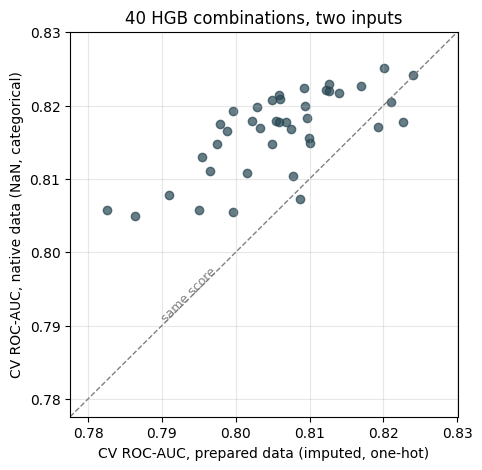

native - prepared: mean +0.0106, native better for 36 of 40 combinations


In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(scores["prepared"], scores["native"], s=36, color="#264653", alpha=0.7)
lims = [scores.min().min() - 0.005, scores.max().max() + 0.005]
ax.plot(lims, lims, color="gray", ls="--", lw=1)
ax.text(lims[0] + 0.012, lims[0] + 0.013, "same score", color="gray", fontsize=9, rotation=45)
ax.set(xlim=lims, ylim=lims, xlabel="CV ROC-AUC, prepared data (imputed, one-hot)",
       ylabel="CV ROC-AUC, native data (NaN, categorical)", title="40 HGB combinations, two inputs")
ax.grid(alpha=0.3)
plt.show()

diff = scores["native"] - scores["prepared"]
print(f"native - prepared: mean {diff.mean():+.4f}, native better for {(diff > 0).sum()} of {len(diff)} combinations")

**Interpretation**
- **Best scores: 0.825 (native) and 0.824 (prepared)**, a small gain over the defaults (0.820). Both stay clearly below the tuned random forest (0.836, notebook 05a).
- The best combinations share a **small learning rate** (mostly about 0.02) and **large leaves** (at least 17 rows). With small steps, early stopping adds trees until the validation loss stops improving (about 300 in the final model, section 5), and large leaves keep single, possibly mislabelled rows from getting a leaf of their own. That is the opposite of the forest, which works best with leaves of 3 rows. The reason is how the two combine their trees: boosting keeps correcting the remaining errors, so without brakes it would chase the flipped labels; the forest averages independent trees, so their individual mistakes cancel out.
- Almost all top combinations use no class weights; as in the other notebooks, class weights barely change the ranking, and the threshold takes care of recall.
- **Native vs. prepared:** the best combinations score the same, but over all 40 combinations the native data is better for 36, by 0.011 on average (the dots are above the diagonal). With one-hot data, HGB only reaches its best score with the right settings; with native categoricals it does well almost always. A likely reason: one split on a native categorical can put a whole group of categories on one side, where one-hot data needs a series of splits, one small column at a time.
- **Answer to the imputation question (notebook 02, section 9.2):** at its best, the model that handles missing values itself does not beat the one with median imputation. So the median does not throw away information that this model could use, which confirms the decision in 02.
- **Decision: we continue with the native variant.** Same best score, more robust to its settings, and a simpler pipeline (no imputation, 11 columns instead of 64).

## 5. Choosing the decision threshold

Exactly as in notebook 05a (section 5): out-of-fold probabilities of the chosen model on the training set, and the highest threshold that still catches 90% of the poisonous mushrooms. The test set stays untouched.

In [6]:
best_hgb = searches["native"].best_estimator_  # the chosen variant, refitted on all training rows
oof = cross_val_predict(clone(best_hgb), X_train_native, y_train, cv=cv, method="predict_proba")[:, 1]


def threshold_for_recall(y_true, p, target):
    # Highest threshold whose recall is still >= target (recall only drops when the threshold rises)
    _, recall, thresholds = precision_recall_curve(y_true, p)
    return thresholds[recall[:-1] >= target].max()


def operating_point(y_true, p, threshold):
    pred = p >= threshold
    return {"threshold": threshold, "recall": recall_score(y_true, pred), "precision": precision_score(y_true, pred),
            "share_of_edible_flagged": (pred & (y_true == 0)).sum() / (y_true == 0).sum()}


threshold = threshold_for_recall(y_train, oof, RECALL_TARGET)
points = {"default threshold 0.5": operating_point(y_train, oof, 0.5),
          f"recall >= {RECALL_TARGET:.2f}": operating_point(y_train, oof, threshold)}
print(f"Out-of-fold ROC-AUC: {roc_auc_score(y_train, oof):.3f}  |  chosen threshold: {threshold:.3f}")
print("Trees in the final model (chosen by early stopping):", best_hgb.named_steps["model"].n_iter_)
pd.DataFrame(points).T.round(3)

Out-of-fold ROC-AUC: 0.824  |  chosen threshold: 0.161
Trees in the final model (chosen by early stopping): 307


,threshold,recall,precision,share_of_edible_flagged
default threshold 0.5,0.500,0.608,0.796,0.095
recall >= 0.90,0.161,0.900,0.482,0.588


**Interpretation**
- Out-of-fold AUC 0.824 (random forest: 0.835). At 0.5 the model catches 61% of the poisonous mushrooms.
- The threshold for 90% recall is **0.16**, much lower than the forest's 0.27. That does not make this model more careful. It uses no class weights, so its probabilities follow the real share of poisonous mushrooms (38%), while the forest's balanced class weights push its probabilities up. A threshold only means something together with its own model, which is why every model stores its own threshold.
- At 90% recall, precision is 0.48 and 59% of the edible mushrooms are flagged (forest: 0.50 and 55%). The slightly weaker ranking costs a few more false alarms for the same recall.

## 6. Test-set evaluation

The final model (chosen hyperparameters, trained on all 4000 training rows) is evaluated **once** on the test set, at threshold 0.5 and at the chosen threshold. The `test_metrics` helper is the same as in notebooks 03–05a.

In [7]:
def test_metrics(name, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


p_test = best_hgb.predict_proba(X_test_native)[:, 1]
results = [
    test_metrics("gradient boosting (tuned)", y_test, p_test, threshold=0.5),
    test_metrics(f"gradient boosting (tuned, recall {RECALL_TARGET:.2f})", y_test, p_test, threshold=threshold),
]
pd.DataFrame(results).set_index("model").drop(columns="notebook").round(3)

,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
model,,,,,,,,
gradient boosting (tuned),0.500,0.802,0.62,0.813,0.704,0.851,144,54
"gradient boosting (tuned, recall 0.90)",0.161,0.646,0.91,0.519,0.661,0.851,34,320


The confusion matrices at both thresholds; the bottom-left cell counts the poisonous mushrooms called edible.

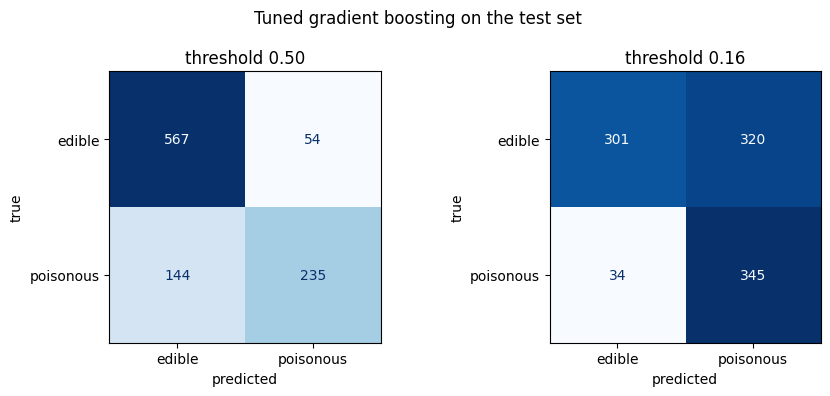

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, t in zip(axes, [0.5, threshold]):
    ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= t).astype(int), display_labels=["edible", "poisonous"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set(title=f"threshold {t:.2f}", xlabel="predicted", ylabel="true")
    ax.grid(False)
fig.suptitle("Tuned gradient boosting on the test set")
plt.tight_layout()
plt.show()

**Interpretation**
- **At threshold 0.5:** AUC 0.851, accuracy 0.802, recall 0.62 (144 poisonous mushrooms missed). The AUC is close to the forest's (0.855), but at 0.5 this model misses more (forest: 119), because it has no class weights pushing its probabilities towards *poisonous*.
- **At threshold 0.16:** recall **0.910**: 345 of the 379 poisonous mushrooms caught, **34 missed**, with 320 false alarms (precision 0.52). The forest at its own threshold: 40 missed and 317 false alarms. So on the test set, gradient boosting is slightly *better* at our operating point, while cross-validation said that the forest ranks better (0.836 vs. 0.825).
- These differences are 6 of 379 poisonous and 3 of 621 edible mushrooms, well within the uncertainty of a single test set of 1000 rows (the AUC has a standard error of about 0.013). The honest conclusion: **at our operating point, both tree ensembles are about equally good.** `07_model_comparison.ipynb` compares them on exactly the same test rows (e.g. with a bootstrap), which is fairer than comparing single numbers.
- Both models score higher on the test set than in cross-validation (here 0.851 vs. 0.825). This test set seems to be a little easier than the average fold, another reason to compare models on the same rows rather than with CV numbers from different notebooks.

## 7. Saving the model for deployment

The chosen model is already a complete pipeline (ordinal encoder + HGB) that takes the cleaned, readable columns, so the API can use it exactly like the baseline and the forest: apply the cleaning of notebook 02 (sections 2–5), call `predict_proba`, and compare the probability with the threshold from the JSON file next to it. It does **not** use the preprocessor from notebook 02: the imputation and one-hot encoding are simply not needed.

The column order of the input is the same as for the other models, which we check.

In [9]:
preprocessor_columns = list(joblib.load(MODEL_DIR / "mushroom_preprocessor.joblib").feature_names_in_)
assert NUM_COLS + CAT_COLS == preprocessor_columns, "Input columns differ from the other deployable models"

joblib.dump(best_hgb, MODEL_PATH, compress=3)
model_info = {
    "model": "gradient boosting (tuned)",
    "notebook": NOTEBOOK,
    "threshold": round(float(threshold), 4),
    "threshold_rule": f"highest threshold with out-of-fold recall (poisonous) >= {RECALL_TARGET} on the training set",
    "cv_roc_auc": round(float(searches["native"].best_score_), 4),
    "hyperparameters": {k.removeprefix("model__"): v.item() if hasattr(v, "item") else v  # NumPy numbers -> plain for JSON
                        for k, v in searches["native"].best_params_.items()},
    "n_trees": int(best_hgb.named_steps["model"].n_iter_),
    "input_columns": NUM_COLS + CAT_COLS,
}
MODEL_INFO_PATH.write_text(json.dumps(model_info, indent=2))
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e3:.0f} KB)  and  {MODEL_INFO_PATH}")
print(json.dumps(model_info, indent=2))

Saved models\mushroom_gradient_boosting.joblib  (1320 KB)  and  models\mushroom_gradient_boosting.json
{
  "model": "gradient boosting (tuned)",
  "notebook": "05b_model_gradient_boosting",
  "threshold": 0.1606,
  "threshold_rule": "highest threshold with out-of-fold recall (poisonous) >= 0.9 on the training set",
  "cv_roc_auc": 0.8251,
  "hyperparameters": {
    "class_weight": null,
    "l2_regularization": 1.5352246941973489,
    "learning_rate": 0.01866188148138769,
    "max_depth": null,
    "max_features": 0.6774801263571897,
    "max_leaf_nodes": 90,
    "min_samples_leaf": 24
  },
  "n_trees": 307,
  "input_columns": [
    "cap_diameter",
    "stem_height",
    "stem_width",
    "has_stem",
    "spore_print_color",
    "gill_color",
    "habitat",
    "season",
    "ring_type",
    "cap_shape",
    "stem_surface"
  ]
}


## 8. Storing the metrics

Both test rows go into the shared `models/metrics.csv`; rows of this notebook are replaced when it is run again.

In [10]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,naive (always edible),03_model_baseline,0.500,0.621,0.000,0.000,0.000,0.500,379,0
1,logistic regression (balanced),03_model_baseline,0.500,0.674,0.599,0.566,0.582,0.710,152,174
2,PyCaret random forest (default),04_model_automl,0.500,0.796,0.609,0.805,0.694,0.840,148,56
3,random forest (tuned),05a_model_random_forest,0.500,0.823,0.686,0.818,0.746,0.855,119,58
4,"random forest (tuned, recall 0.90)",05a_model_random_forest,0.266,0.643,0.894,0.517,0.655,0.855,40,317
5,gradient boosting (tuned),05b_model_gradient_boosting,0.500,0.802,0.620,0.813,0.704,0.851,144,54
6,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,0.161,0.646,0.910,0.519,0.661,0.851,34,320


## 9. Conclusion & next steps

- **Tuned gradient boosting:** CV AUC 0.825, test AUC 0.851. With the threshold of 0.16 it catches 91% of the poisonous test mushrooms (34 missed) at the cost of 320 false alarms out of 621 edible mushrooms.
- **What works for boosting:** a small learning rate with early stopping, and large leaves. Boosting needs brakes against the label noise; the random forest needs the opposite (small leaves), because its averaging already removes the noise.
- **Native missing values and categoricals** give the same best score as median imputation + one-hot, but are much more robust across hyperparameters. The median imputation of notebook 02 does not lose useful information.
- **Compared with the random forest:** the forest ranks better in cross-validation (0.836 vs. 0.825); at our operating point on the test set they are equal within the noise. The boosting model is much smaller (1.3 MB vs. 18 MB) and faster, a real argument for deployment. The choice is made in `07_model_comparison.ipynb`.
- **Deployable:** `models/mushroom_gradient_boosting.joblib` (encoder + HGB, takes the cleaned columns like the other models) with `models/mushroom_gradient_boosting.json` (threshold 0.161).

**Next steps**
- `06_model_aws.ipynb`: XGBoost on AWS SageMaker with SageMaker's hyperparameter tuning, on the same split and with the same threshold rule.
- `07_model_comparison.ipynb`: all models on the same test rows, uncertainty of the differences, permutation importance and error analysis.